In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from toolbox import boxplots

file = "data/level1/dwh_mkn_meteo_1h_20170101000000-20240101000000.parquet"
df = pl.read_parquet(file)

# Convert 'dtm' column to datetime if it's not already in datetime format
df = df.with_columns(pl.col('dtm').cast(pl.Datetime))
df = df.with_columns(pl.col('dtm').dt.date().alias('dte'))

# Select data that ae flagged as 'valid' (flag==0)
df = df.filter((pl.col('f_tre200h0')==0) & (pl.col('f_ure200h0')==0) & (pl.col('f_rre150h0')==0))

vars = ['tre200h0', 'ure200h0', 'gre000h0', 'rre150h0']
labels = [f"temperature 2m (°C) [{vars[0]}]", f"relative humidity 2m (%) [{vars[1]}]", 
          f"global radiation (W/m2) [{vars[2]}]", f"precipitation (mm/h) [{vars[3]}]",]

labels_hourly_means = ["Hourly mean  " + label for label in labels]
labels_daily_means = ["Daily mean " + label for label in labels]
period = f"{min(df['dte'])} thru {max(df['dte'])}"
suptitle = f"Mount Kenya GAW Station (MKN) {period}"
title = '(c) MeteoSwiss, Kenya Meteorological Department'

df.describe()

statistic,station,termin,tre200h0,prestah0,ure200h0,fkl010h0,dkl010h0,rre150h0,gre000h0,dtm,f_station,f_tre200h0,f_prestah0,f_ure200h0,f_fkl010h0,f_dkl010h0,f_rre150h0,f_gre000h0,f_termin,dte
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",13822.0,13822.0,13822.0,13822.0,13822.0,13778.0,13761.0,13822.0,11446.0,"""13822""",0.0,13822.0,13822.0,13822.0,13778.0,13761.0,13822.0,11446.0,0.0,"""13822"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,44.0,61.0,0.0,2376.0,"""0""",13822.0,0.0,0.0,0.0,44.0,61.0,0.0,2376.0,13822.0,"""0"""
"""mean""",10769.0,2.0219e13,6.621668,661.406801,73.66588,4.459247,159.215609,0.162798,181.851739,"""2022-04-28 20:…",null,0.0,0.0,0.0,0.021919,0.021946,0.0,0.0,null,"""2022-04-28"""
"""std""",0.0,1.3993e10,2.36403,1.163953,17.588708,2.569851,94.921806,1.14594,267.571104,null,null,0.0,0.0,0.0,0.208232,0.20836,0.0,0.0,null,null
"""min""",10769.0,2.0190e13,0.3,657.6,10.1,0.0,0.0,0.0,0.0,"""2019-03-24 16:…",null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,"""2019-03-24"""
"""25%""",10769.0,2.0211e13,4.8,660.6,63.3,2.4,104.0,0.0,0.0,"""2021-12-20 18:…",null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,"""2021-12-20"""
"""50%""",10769.0,2.0221e13,6.2,661.4,77.6,4.0,137.0,0.0,14.0,"""2022-11-06 07:…",null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,"""2022-11-06"""
"""75%""",10769.0,2.0231e13,8.3,662.2,87.1,6.1,225.0,0.0,289.0,"""2023-05-10 12:…",null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,"""2023-05-10"""
"""max""",10769.0,2.0231e13,14.5,665.2,98.8,29.6,360.0,25.7,1200.0,"""2023-10-19 09:…",null,0.0,0.0,0.0,2.0,2.0,0.0,0.0,null,"""2023-10-19"""


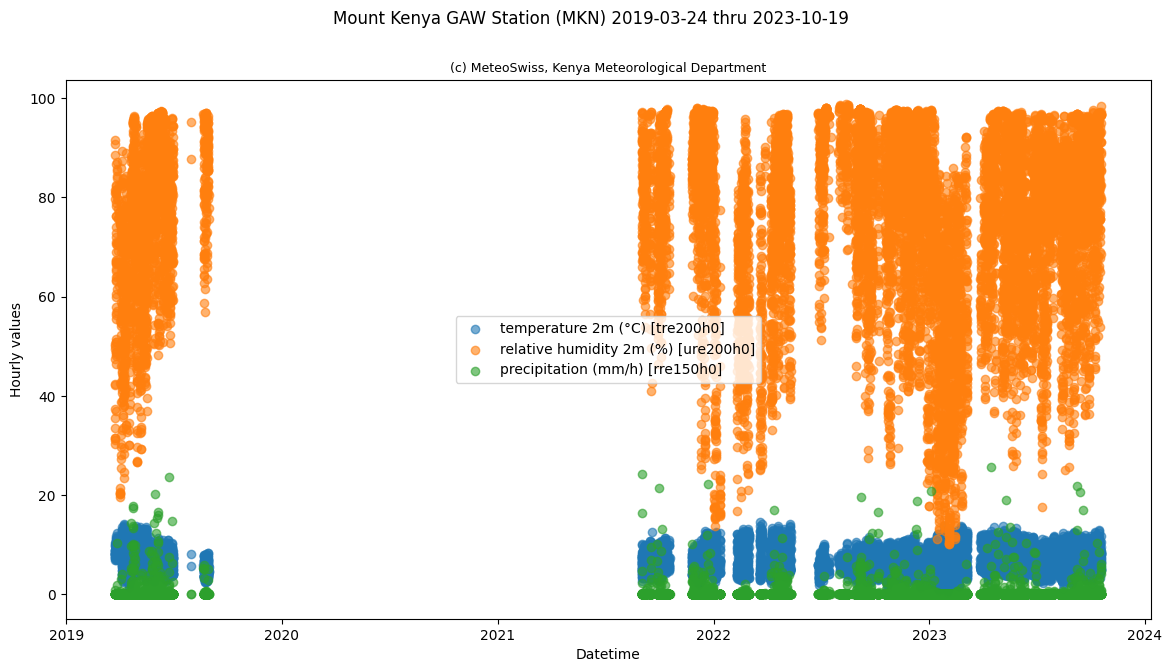

In [2]:
# Scatter plot for time series data
plt.figure(figsize=(14, 7))
plt.scatter(df['dtm'].to_pandas(), df[vars[0]].to_pandas(), label=labels[0], alpha=0.6)
plt.scatter(df['dtm'].to_pandas(), df[vars[1]].to_pandas(), label=labels[1], alpha=0.6)
plt.scatter(df['dtm'].to_pandas(), df[vars[3]].to_pandas(), label=labels[3], alpha=0.6)

plt.xlabel('Datetime')
plt.ylabel('Hourly values')
plt.legend()
plt.suptitle(suptitle)
plt.title(title, size=9)
plt.show()

<Figure size 700x500 with 0 Axes>

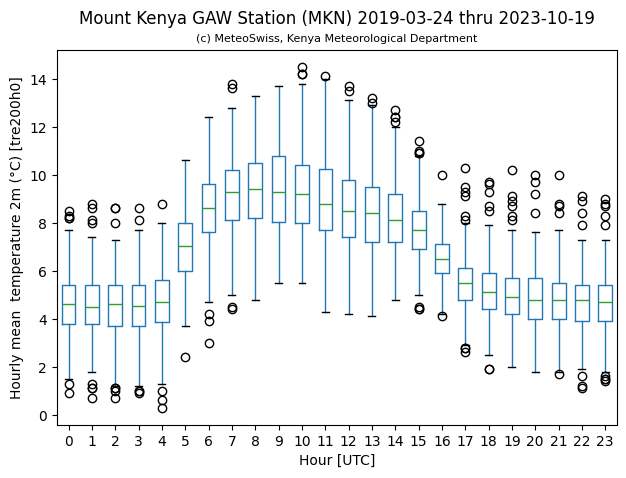

<Figure size 700x500 with 0 Axes>

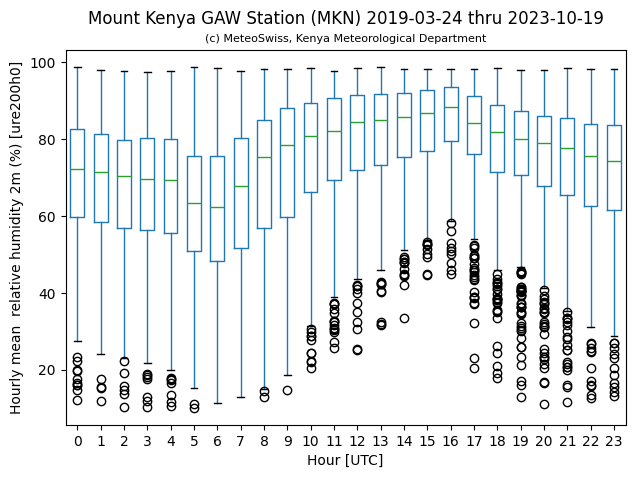

<Figure size 700x500 with 0 Axes>

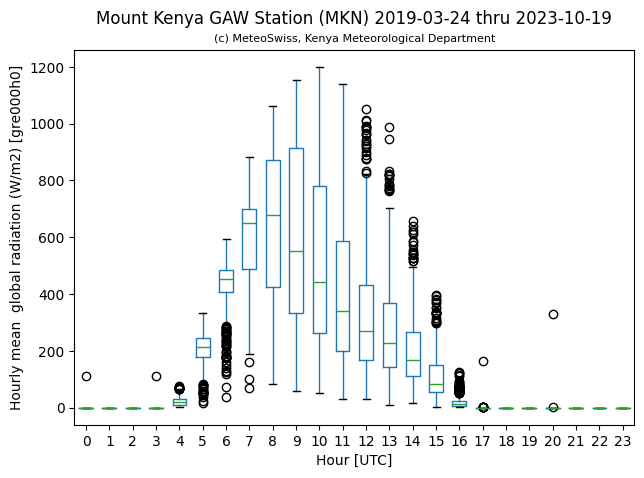

<Figure size 700x500 with 0 Axes>

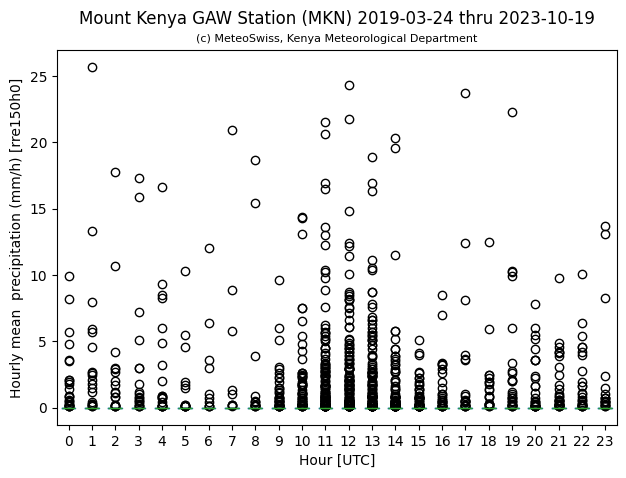

In [7]:
# Diurnal variation boxplots
for i in range(4):  
    boxplots.box_plot(df=df, var=vars[i], by='Hour [UTC]', suptitle=suptitle, title=title, ylabel=labels_hourly_means[i])

<Figure size 700x500 with 0 Axes>

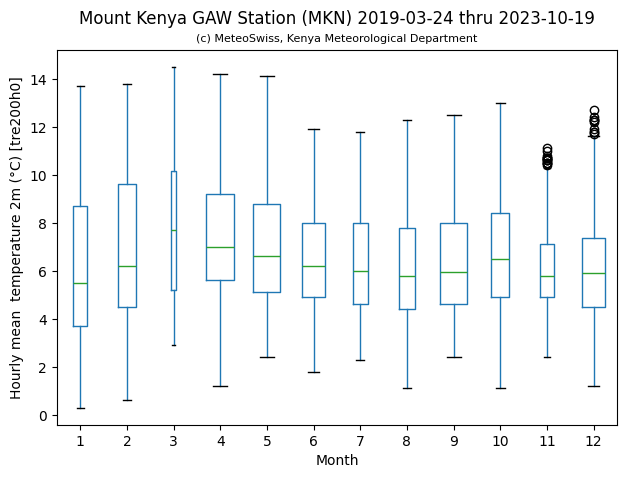

<Figure size 700x500 with 0 Axes>

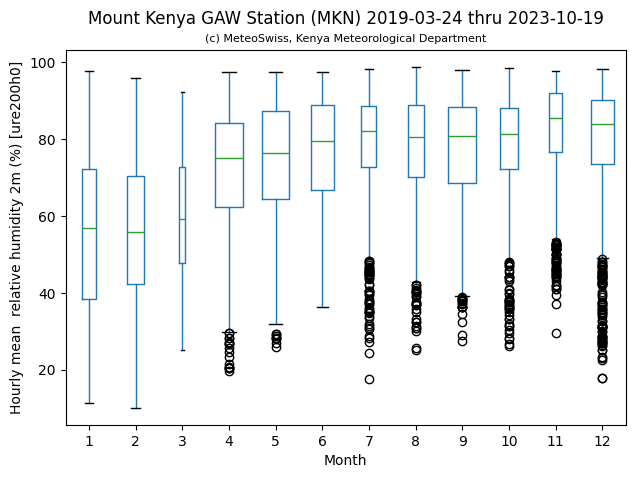

<Figure size 700x500 with 0 Axes>

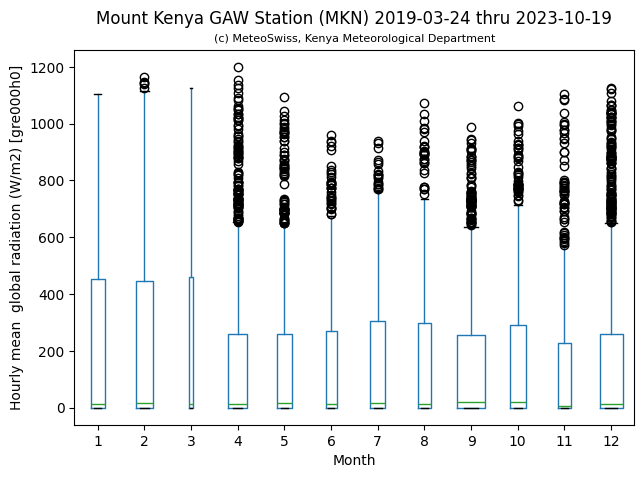

<Figure size 700x500 with 0 Axes>

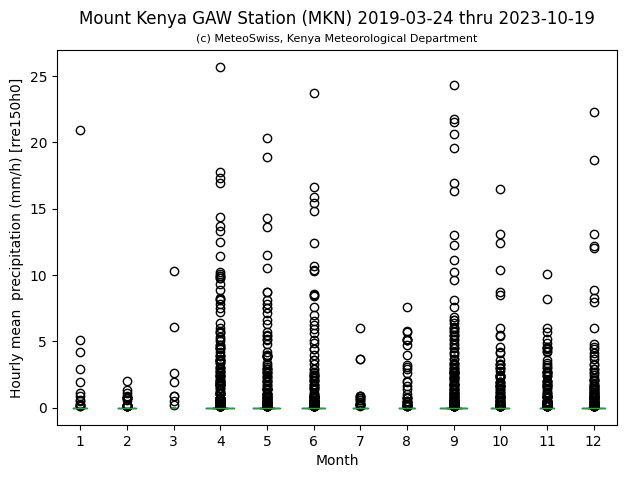

In [4]:
# Seasonal variation of hourly mean values boxplots
for i in range(4):  
    boxplots.box_plot(df=df, var=vars[i], by='Month', suptitle=suptitle, title=title, ylabel=labels_hourly_means[i])

<Figure size 700x500 with 0 Axes>

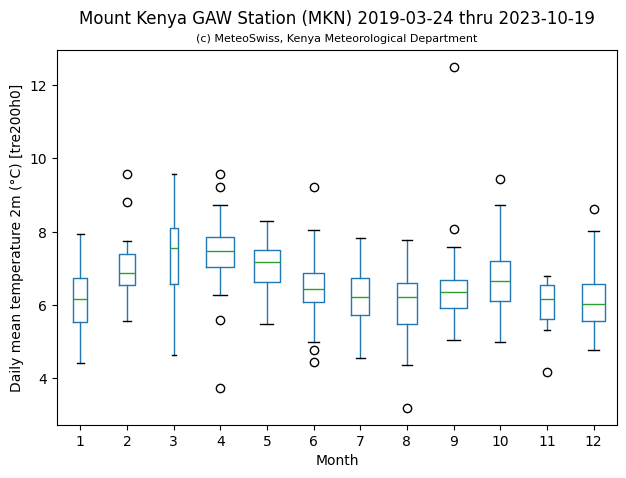

<Figure size 700x500 with 0 Axes>

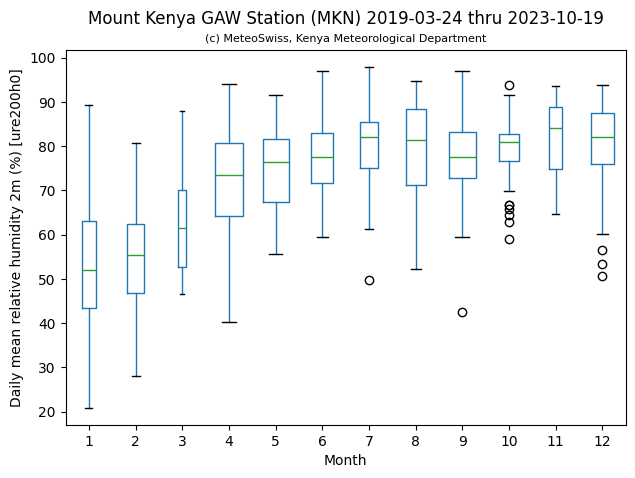

<Figure size 700x500 with 0 Axes>

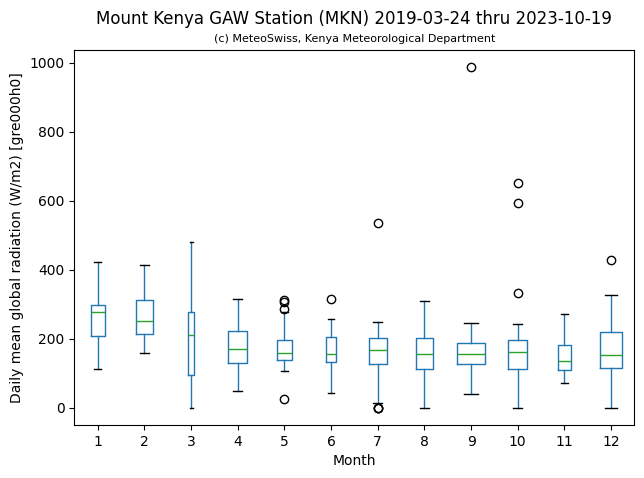

In [2]:
# Seasonal variation of daily means boxplots
for i in range(3):  
    boxplots.daily_mean_monthly_box_plot(df=df, var=vars[i], suptitle=suptitle, title=title, ylabel=labels_daily_means[i])

<Figure size 700x500 with 0 Axes>

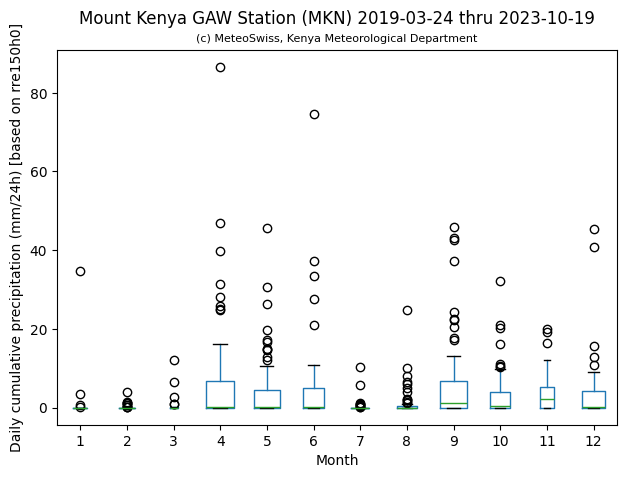

In [6]:
var = 'rre150h0'
ylabel = f"Daily cumulative precipitation (mm/24h) [based on {var}]"
df_precip = boxplots.daily_cumsum_monthly_box_plot(df=df, var=var, suptitle=suptitle, title=title, ylabel=ylabel)